In [1]:
import numpy as np
import time
import datetime
import matplotlib.pyplot as plt
import scipy.io as sio
import os
import sys
import math
from scipy.interpolate import griddata, interpn
import mat73
import trimesh
import pickle
import copy
import pprint

In [2]:
'defs'
def rotate_point_cloud_to_align_vector(points, vector):
    # Normalize the input vector
    v = vector / np.linalg.norm(vector)

    # Target axis (z-axis)
    z_axis = np.array([0, 0, 1])

    # Compute rotation axis using cross product
    axis = np.cross(v, z_axis)
    axis_norm = np.linalg.norm(axis)

    # If the axis norm is zero, the vector is already aligned with z-axis
    if axis_norm < 1e-10:
        return points, vector

    axis = axis / axis_norm

    # Compute rotation angle using dot product
    angle = np.arccos(np.clip(np.dot(v, z_axis), -1.0, 1.0))

    # Rodrigues' rotation formula
    K = np.array([
        [0, -axis[2], axis[1]],
        [axis[2], 0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])

    R = np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)

    # Rotate points and vector
    rotated_points = points @ R.T
    rotated_vector = vector @ R.T

    return rotated_points

def align_to_normal(points, new_normal, prev_normal):
    # Normalize vectors
    z_axis = prev_normal #this is the z-axis in the first iteration but should be in all
    normal = np.array(new_normal) / np.linalg.norm(new_normal)
    
    # Compute rotation using Rodrigues' formula
    a = z_axis
    b = normal
    v = np.cross(a, b)
    c = np.dot(a, b)
    s = np.linalg.norm(v)
    
    if s == 0:
        return points.copy()  # Already aligned
    
    # Skew-symmetric matrix
    k_mat = np.array([[0, -v[2], v[1]],
                    [v[2], 0, -v[0]],
                    [-v[1], v[0], 0]])
    
    R = np.eye(3) + k_mat + (k_mat @ k_mat) * ((1 - c) / (s ** 2))
    
    # Apply rotation
    rotated_points = points @ R.T
    return rotated_points


def closest_meshes_to_point(mesh,point):

    # Compute centroids of all faces
    face_vertices = mesh.vertices[mesh.faces]  # Shape: (num_faces, 3, 3)
    centroids = face_vertices.mean(axis=1)     # Shape: (num_faces, 3)

    # Compute distances from point to each centroid
    distances = np.linalg.norm(centroids - point, axis=1)

    # Get indices of 10 closest faces
    closest_indices = np.argsort(distances)[:10]

    # For each face, compute centroid and normal
    results = []
    for face_idx in closest_indices:
        verts_idx = mesh.faces[face_idx]
        verts = mesh.vertices[verts_idx]

        centroid = centroids[face_idx]
        normal = mesh.face_normals[face_idx]

        results.append({
            "face_index": face_idx,
            "centroid": centroids[face_idx],
            "normal": mesh.face_normals[face_idx],
            "face_vertex_indices": verts_idx,
            "face_vertices": verts
        })

    return results

def es_matrix_matf(E_x,E_y,E_z,dx,center,center_coord=None):
    # E_x,E_y,E_z in V/m
    # dx in um
    if (E_x.shape != E_y.shape) or (E_x.shape != E_z.shape):
        print("-"*10,"dimensions of Ex,Ey and Ez are not the same!","-"*10)
    es_shape = E_x.shape
    cx, cy, cz = center
    # these coordinates are for even shapes and assuming that the middle of the matrix is in the origin
    # x_coord = np.arange(-es_shape[0]//2+1/2,es_shape[0]//2) *dx # neuron works in um but these values are in mm!
    # y_coord = np.arange(-es_shape[1]//2+1/2,es_shape[1]//2) *dx # need of length conversion so it matches
    # z_coord = np.arange(-es_shape[2]//2+1/2,es_shape[2]//2) *dx
    #x_coord = np.arange(-cx,es_shape[0]-cx) * dx
    if center_coord: #if the exact coordinates are given instead of the indexes (more neuron placement precision is needed)
        ccx, ccy, ccz = center_coord
    else:
        ccx, ccy, ccz = cx*dx, cy*dx, cz*dx
    x_coord = np.arange(-ccx,es_shape[0]*dx-ccx,dx)
    y_coord = np.arange(-ccy,es_shape[1]*dx-ccy,dx)
    z_coord = np.arange(-ccz,es_shape[2]*dx-ccz,dx)
    xv,yv,zv = np.meshgrid(x_coord,y_coord,z_coord,indexing='ij')
    #print(xv,yv,zv)
    es_mat = -(E_x*xv + E_y*(-zv) + E_z*yv)*1e-3
    return es_mat, x_coord, y_coord, z_coord

def TaitBryan2rotMat(theta) :
	"""  Calculates Rotation Matrix given Tait-Bryan angles.
	theta = [phi,theta,psi] Tait-Bryan angles """      
	R_x = np.array([[1,         0,                  0                   ],
					[0,         math.cos(theta[0]), -math.sin(theta[0]) ],
					[0,         math.sin(theta[0]), math.cos(theta[0])  ]
					])         
	R_y = np.array([[math.cos(theta[1]),    0,      math.sin(theta[1])  ],
					[0,                     1,      0                   ],
					[-math.sin(theta[1]),   0,      math.cos(theta[1])  ]
					])
                 
	R_z = np.array([[math.cos(theta[2]),    -math.sin(theta[2]),    0],
					[math.sin(theta[2]),    math.cos(theta[2]),     0],
					[0,                     0,                      1]
					])                  
	R = np.dot(R_z, np.dot( R_y, R_x ))
	return R


def findSOMA():
	for sec in h.allsec():
		if h.ismembrane("xtra"):
			if (sec.type_xtra==1):
				return [sec.x_xtra, sec.y_xtra, sec.z_xtra]
               

def calcThresh(xSOM,ySOM,zSOM,phi,theta,psi,DEL,DUR,Ancat):
	h.DEL = DEL
	h.DUR = DUR
	#h.dt = min(DUR/TpRefdt,dtMAX) ## I change this in the thresh_(log)freq function instead
	h.steps_per_ms = 1/h.dt				# Circumvent setdt()-function in stdinit
	#h.tstop = max(TpRefT*DUR,Tmin) ## I change this in the thresh_(log)freq function instead
	if (h.name_declared("apc")==0):
		h("objref apc")
		h("apc = new APCount(0.5)")
	h("stimamp = 1")
	h("ANCAT = 1")
	h.ANCAT = (-1)**Ancat 
	#print(h.ANCAT)
	h("func thresh_excited() {setstim(DEL,DUR,ANCAT*stimamp) AMP = ANCAT*stimamp run() return apc.n > 0}")
	[xSOM0,ySOM0,zSOM0] = findSOMA()
	#calcESext(xSOM-xSOM0,ySOM-ySOM0,zSOM-zSOM0,phi,theta,psi)
	threshold = h.threshold(h._ref_stimamp)
	print("interp3D",h.dt,h.tstop)
	return h.ANCAT*threshold
	
def calcThreshSimpl(xSOM,ySOM,zSOM,DEL,DUR,Ancat):
	return calcThresh(xSOM,ySOM,zSOM,0,0,0,DEL,DUR,Ancat)

def calcESext3(xT,yT,zT,new_normal,prev_normal,InterpolMethod,Arrayx,Arrayy,Arrayz,x,y,z): ##
    """ (xT,yT,zT) is translation vector, (phi,theta,psi) are Tait-Bryan extrinsic roll-pitch-yaw angles """
    xSOM,ySOM,zSOM = findSOMA()
    i=0
    for sec in h.allsec():
        if h.ismembrane("xtra"):
            for seg in sec:
                if "Scale" not in str(seg) and "Elec" not in str(seg) and "ExcNode" not in str(seg): ##
                    i=i+1
                    #print(i) if (i%100 == 0) else None ##
                    xp, yp, zp = seg.x_xtra,seg.y_xtra,seg.z_xtra
                    x90, y90,z90 = xp, -zp, yp
                    [xD,yD,zD] = align_to_normal(np.array([x90,y90,z90]),new_normal,prev_normal)+[xT,yT,zT]
                    if 'soma' in str(seg):
                        print(f'seg.x_xtra,seg.y_xtra,seg.z_xtra: {seg.x_xtra,seg.y_xtra,seg.z_xtra}')
                        print(f'xD,yD,zD: {xD,yD,zD}')
                    ax.scatter(xD,yD,zD,c='r')
                    seg.Ex_xtra = interpn((x,y,z),Arrayx,\
                    [xD,yD,zD],method=InterpolMethod,fill_value=0,bounds_error=False) # [V/m]
                    seg.Ey_xtra = interpn((x,y,z),Arrayy,\
                    [xD,yD,zD],method=InterpolMethod,fill_value=0,bounds_error=False) # [V/m]
                    seg.Ez_xtra = interpn((x,y,z),Arrayz,\
                    [xD,yD,zD],method=InterpolMethod,fill_value=0,bounds_error=False) # [V/m]

In [3]:
"cell and field initialization"


# increases the stack in able to load cell_nr = 6
nrn_options = "-NSTACK 10000 -NFRAME 525"
# nrn_options = "-nogui -NSTACK 3000 -NFRAME 525"
os.environ["NEURON_MODULE_OPTIONS"] = nrn_options
from neuron import h, gui

h("NSTACK_size = 10000")

h.load_file('init.hoc')
h.load_file('thresh4.hoc') 
h.load_file('get_es2.hoc') #for TMS
h.load_file('interp_coordinates.hoc') #for TMS (to calc Dx,Dy and Dz)

cell_nr = 7
h.setParamsAdultHuman() #this needs to go before the cell chooser, otherwise it won't make a difference
h.cell_chooser(cell_nr)
#print(h.topology()) #print this to decide the code for the cell below
if cell_nr == 2:
    cell = h.bNAC219_L1_NGCDA_e7cec642c3[0] # for cell = 2
elif cell_nr == 3:
    cell = h.bNAC219_L1_NGCDA_46b45974f4[0] # for cell = 3
elif cell_nr == 7:
    cell = h.cADpyr229_L23_PC_8ef1aa6602[0] # for cell = 7


current_time = datetime.datetime.now()
now = datetime.datetime.strftime(current_time,'%d_%m_%Y_%H_%M_%S')

	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	1 
	1 
	1 
	1 
	1 
	1 
	1 
	1 
	1 
*---------*
Loaded Blue Brain cell: L23_PC_cADpyr229_2
Got main axon (method 2)
Myelinating axon: Replacing 48 Axonal sections w/ 84 Myelin, 84 Node, 11 Unmyelin sections
Adding myelin before the 1st bifurcation
Scaled diameter of myelin sections using variable g-ratio
Inserted xtra and extracellular in all 610 compartments
Got main axon (method 2)
Cell Loaded


In [4]:
'loading in matf and trimesh'
TMS = 0 #also use the right x86 folder and change save folder
Eunif = 0 #also use the right x86 folder and change save folder
Bunif = 1 #same nrnmech.dll file as TMS (or folder on linux) 

interpol = 'linear'
logspace = (10,2,5)
dt_fact = 100
dx = 0.49997*1e3 #um

time_start = datetime.datetime.now()
subject = 3
direction = 'lateral' #anterior #lateral #superior 

name = "interpol_"+str(interpol)+"_logspace_"+str(logspace)+"_cell_nr_"+str(cell_nr)+"_dt_fact_"+str(dt_fact)+"_subject_"+str(subject)+"_direction_"+direction

print(f'subject: {subject}, direction: {direction}')
#h.cvode_active(1)

numb_freq, logstart, logstop = logspace
dt_factor = dt_fact

#first change the NEURON axes to the python axes to align the coordinate systems
for sec in h.allsec():
    for seg in sec:
        if 'soma' in str(seg):
            segment = seg
print('loading matf')
matf300,matf100k = mat73.loadmat(rf'Exyz\s{subject}_300Hz.mat'), mat73.loadmat(rf'Exyz\s{subject}_100kHz.mat') #"300Hz" if freq < 1e4 else "100KHz"
print('loaded matf')
brainmap = matf300['TissueTypeIndices'] #should be the same as matf100k['TissueTypeIndices']
E_x300, E_y300, E_z300 = matf300['E'][direction]['x'], matf300['E'][direction]['y'], matf300['E'][direction]['z']
E_x100k, E_y100k, E_z100k = matf100k['E'][direction]['x'], matf100k['E'][direction]['y'], matf100k['E'][direction]['z']
E_mag300 = np.sqrt(E_x300**2+E_y300**2+E_z300**2)
E_mag100k = np.sqrt(E_x100k**2+E_y100k**2+E_z100k**2)
E_mag300_GM = (E_mag300*(brainmap==16)).flatten()
E_mag100k_GM = (E_mag100k*(brainmap==16)).flatten()
E_max_GM300 = np.max(E_mag300*(brainmap==16))
E_max_GM100k = np.max(E_mag100k*(brainmap==16))
E_max_GM300_99 = np.percentile(E_mag300_GM[E_mag300_GM != 0],99)
E_max_GM100k_99 = np.percentile(E_mag100k_GM[E_mag100k_GM != 0],99)
print(f'300 Hz: max: {E_max_GM300} , 99 percentile: {E_max_GM300_99}')
print(f'100 kHz: max: {E_max_GM100k} , 99 percentile: {E_max_GM100k_99}')
E_max_GM300loc = np.unravel_index(np.argmax(E_mag300*(brainmap==16)),E_mag300.shape)
E_max_GM100kloc = np.unravel_index(np.argmax(E_mag100k*(brainmap==16)),E_mag100k.shape)
meshname = 'layer_1_depth_0.06' if cell_nr < 6 else 'layer_23_depth_0.40' if cell_nr < 11 else 'layer_4_depth_0.55' if cell_nr < 16 else 'layer_5_depth_0.65' if cell_nr < 21 else 'layer_6_depth_0.85' if cell_nr <26 else 'ERROR'

print('loading trimesh')
surface_mesh = trimesh.load_mesh(rf"tissue_meshes\subjects\s{subject}\layers\{meshname}.stl")
print('loaded trimesh')
polygons300 = closest_meshes_to_point(surface_mesh,E_max_GM300loc)
polygons100k = closest_meshes_to_point(surface_mesh,E_max_GM100kloc) if E_max_GM300loc != E_max_GM100kloc else []
polygons = polygons300 + polygons100k
pprint.pprint(polygons)

results = {'hotspot_300': {key: {} for key in range(10)}, 'hotspot_100k': {key: {} for key in range(10)}}

subject: 3, direction: lateral
loading matf
loaded matf
300 Hz: max: 0.22592906653881073 , 99 percentile: 0.12579545676708231
100 kHz: max: 68.38414001464844 , 99 percentile: 39.697607955932625
loading trimesh
loaded trimesh
[{'centroid': TrackedArray([159.08558655,  87.06923676, 323.14275106]),
  'face_index': 1896416,
  'face_vertex_indices': TrackedArray([950590, 950591, 939433], dtype=int64),
  'face_vertices': TrackedArray([[159.08558655,  86.96923828, 323.04275513],
              [159.3855896 ,  86.96923828, 323.34274292],
              [158.7855835 ,  87.2692337 , 323.04275513]]),
  'normal': array([-0.57733559, -0.57735027,  0.57736495])},
 {'centroid': TrackedArray([159.08558655,  86.86923726, 323.14275106]),
  'face_index': 1896281,
  'face_vertex_indices': TrackedArray([950591, 950590, 939365], dtype=int64),
  'face_vertices': TrackedArray([[159.3855896 ,  86.96923828, 323.34274292],
              [159.08558655,  86.96923828, 323.04275513],
              [158.7855835 ,  86.6

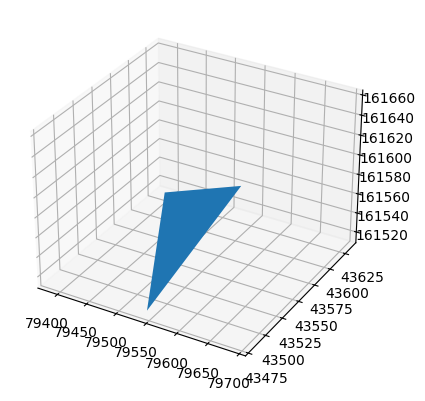

In [ ]:
plot_polygon = 0
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

if plot_polygon:

    mesh = surface_mesh
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_trisurf(
        polygons[0]['face_vertices'][:,0]*dx, 
        polygons[0]['face_vertices'][:,1]*dx, 
        polygons[0]['face_vertices'][:,2]*dx,
        triangles=[[0,1,2]], 
    ) 
    plt.show()

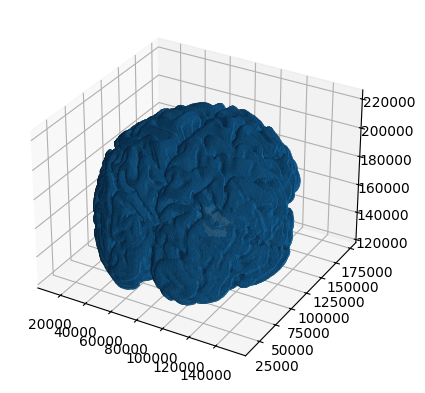

In [6]:
plot_whole_mesh = 0
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

if plot_whole_mesh:
    mesh = surface_mesh
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_trisurf(
        mesh.vertices[:, 0]*dx, 
        mesh.vertices[:, 1]*dx, 
        mesh.vertices[:, 2]*dx,
        triangles=mesh.faces, 
    ) 
    plt.show()

In [7]:
mesh_reducer = 1
if mesh_reducer:
    mesh = surface_mesh
    mesh_dx = mesh.vertices*dx
    print(mesh_dx.shape)
    print(mesh.faces.shape)
    mesh_centroids_dx = mesh.triangles_center*dx
    print(mesh_centroids_dx.shape)
    print(f'bounding box: {np.min(mesh_centroids_dx[:,0])}, {np.max(mesh_centroids_dx[:,0])}, {np.min(mesh_centroids_dx[:,1])}, {np.max(mesh_centroids_dx[:,1])}, {np.min(mesh_centroids_dx[:,2])}, {np.max(mesh_centroids_dx[:,2])}')
    #12441.52151760737, 151333.93699707033, 15824.906339556377, 173002.2077456665, 120511.62873168946, 223602.72276143395
    #[ 79235.27143845  43515.45150624 161773.81654859]
    point1 = np.array([158.48005168,  87.03612518, 323.56704712])*dx
    print(point1)
    mesh_to_point = np.linalg.norm(mesh_dx-point1,axis=1)
    print(mesh_to_point)
    print(np.min(mesh_to_point),np.max(mesh_to_point))
    print(mesh_to_point.shape)



    # 2. Bounds
    drange = 2*1e3
    bounds_min = np.array([point1[0] - drange, point1[1] - drange, point1[2] - drange])
    bounds_max = np.array([point1[0] + drange, point1[1] + drange, point1[2] + drange])

    # 3. Mask faces by centroid
    mask = np.all((mesh_centroids_dx >= bounds_min) & (mesh_centroids_dx <= bounds_max), axis=1)

    # 4. Filter faces
    kept_faces = mesh.faces[mask]

    # 5. Extract used vertices & remap
    unique_indices, inverse_index = np.unique(kept_faces.flatten(),
                                            return_inverse=True)

    new_vertices = mesh.vertices[unique_indices]
    new_faces = inverse_index.reshape(kept_faces.shape)

    # 6. Create new mesh
    filtered_mesh = trimesh.Trimesh(vertices=new_vertices,
                                    faces=new_faces,
                                    process=False)

(2000052, 3)
(4003368, 3)
(4003368, 3)
bounding box: 11942.368767458598, 151833.97820048014, 15334.805958627067, 173523.46247924806, 119969.71483734132, 224062.00509867352
[ 79235.27143845  43515.45150624 161773.81654859]
[85667.94697508 85782.59231739 85875.36047351 ... 87590.2714537
 87393.82565223 87749.09206628]
249.77109589772223 130882.31306878959
(2000052,)


In [9]:
plot_part_mesh = 1
%matplotlib qt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

if plot_part_mesh:
    mesh = surface_mesh
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_trisurf(
        filtered_mesh.vertices[:, 0]*dx, 
        filtered_mesh.vertices[:, 1]*dx, 
        filtered_mesh.vertices[:, 2]*dx,
        triangles=filtered_mesh.faces, 
    ) 
    plt.show()

In [ ]:
def plot_neuron(normal):
    new_normal = normal
    i = 0
    with open(r"C:\Users\jgazquez\IEEE_ICES_TG8_paper\AberraEtAl2018\tissue_meshes\subjects\s3\layers\coords_cell7_s3_lateral_voxels.txt",'a') as fcoord:
        for sec in h.allsec():
            if h.ismembrane("xtra"):
                for seg in sec:
                    if "Scale" not in str(seg) and "Elec" not in str(seg) and "ExcNode" not in str(seg): ##
                        i=i+1
                        #print(i) if (i%20 == 0) else None ##
                        #first change the NEURON axes to the python axes to align the coordinate systems
                        xp, yp, zp = seg.x_xtra,seg.y_xtra,seg.z_xtra
                        #plt.scatter(xp,yp,c='k')
                        #ax.scatter(xp,yp,zp,c='k')
                        x90, y90,z90 = xp, -zp, yp
                        #then rotate the neuron (if necessary, otherwise [0,0,1])
                        [xD,yD,zD] = align_to_normal(np.array([x90,y90,z90]),new_normal,prev_normal)+[xT,yT,zT]
                        e = str(seg)
                        color = 'yellow' if 'soma' in e else 'purple' if 'axon' in e else '#FF0000' if 'Node' in e else '#FFA500' if 'Unmyelin' in e else '#000000' if 'Myelin' in e else '#0000FF' if 'apic' in e else '#00FF00' if 'den' in e else None
                        plt.scatter(yD,zD,c=color)
                        #if 'soma' in e:
                        fcoord.write(f'{xD/dx},{yD/dx},{zD/dx}\n')
                        #ax.scatter(xD,yD,zD,c=color)

D3 = 0 #3D figure
if D3:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection='3d')

    # ax.plot_trisurf(
    #     polygons[0]['face_vertices'][:,0]*dx, 
    #     polygons[0]['face_vertices'][:,1]*dx, 
    #     polygons[0]['face_vertices'][:,2]*dx,
    #     triangles=[[0,1,2]], 
    # ) 
plot_only_neuron = 1
if plot_only_neuron:
    "plot neuron in 2D (or 3D)"
    prev_normal = np.array([0,0,1])
    for i_p,polygon in enumerate(polygons[0:1]):
        location, normal = polygon['centroid'], polygon['normal']
        print(f'location_{i_p}: {location}, {normal} ({subject},{direction})')
        #then rotate the neuron (if necessary, otherwise [0,0,1])
        _,x_values,y_values,z_values = es_matrix_matf(E_x300,E_y300,E_z300,dx,location) #E_x, E_y and E_z are only used for the shape in this case so doesn't matter which freq: 300 or 100k


        xT,yT,zT = location*dx
        print(location,dx)
        plot_neuron(normal)

        #plt.show()

plot_part_mesh = 0
if plot_part_mesh:
    mesh = surface_mesh
    ax.plot_trisurf(
        filtered_mesh.vertices[:, 0]*dx, 
        filtered_mesh.vertices[:, 1]*dx, 
        filtered_mesh.vertices[:, 2]*dx,
        triangles=filtered_mesh.faces, 
    ) 
    plt.show()

location_0: [159.08558655  87.06923676 323.14275106], [-0.57733559 -0.57735027  0.57736495] (3,lateral)
[159.08558655  87.06923676 323.14275106] 499.97


In [21]:
"intersection with plane x = a"
plot_x_a = 1
%matplotlib qt

import struct
import math
import os
from typing import List, Tuple, Optional, Dict
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# STL Parsing (Binary + ASCII)
# ----------------------------

def read_stl_triangles(path: str) -> np.ndarray:
    """
    Returns triangles as an (N, 3, 3) float32 array.
    Each triangle is 3 vertices (v0, v1, v2), each vertex is (x, y, z).
    Supports binary and ASCII STL. Prefers binary if structure matches.
    """
    with open(path, 'rb') as f:
        data = f.read()

    # Try binary
    if len(data) >= 84:
        header = data[:80]
        tri_count = struct.unpack('<I', data[80:84])[0]
        expected_len = 84 + tri_count * 50
        if expected_len == len(data):
            # Likely binary STL
            tris = np.empty((tri_count, 3, 3), dtype=np.float32)
            offset = 84
            for i in range(tri_count):
                # normal(12 bytes) + 3 verts(36 bytes) + attr(2 bytes) = 50 bytes
                # Unpack 12 floats (normal + 9 vertex coords) and a ushort attribute
                floats = struct.unpack('<12fH', data[offset:offset+50])
                v0 = floats[3:6]
                v1 = floats[6:9]
                v2 = floats[9:12]
                tris[i, 0] = v0
                tris[i, 1] = v1
                tris[i, 2] = v2
                offset += 50
            return tris

    # Fallback ASCII
    try:
        text = data.decode('utf-8', errors='ignore')
    except Exception as e:
        raise ValueError(f"Failed to parse STL as binary and ASCII: {e}")

    verts = []
    for line in text.splitlines():
        line = line.strip()
        if line.startswith('vertex'):
            parts = line.split()
            # "vertex x y z"
            if len(parts) >= 4:
                x, y, z = map(float, parts[1:4])
                verts.append((x, y, z))
    if len(verts) % 3 != 0 or len(verts) == 0:
        raise ValueError("ASCII STL parse error: vertex lines not in multiples of 3.")
    tris = np.array(verts, dtype=np.float32).reshape((-1, 3, 3))
    return tris

# ---------------------------------
# Triangle-Plane Intersection (x=c)
# ---------------------------------

def intersect_segment_with_x_plane(p0: np.ndarray, p1: np.ndarray, x0: float, eps: float) -> Optional[np.ndarray]:
    """
    Intersect segment p0->p1 with plane x = x0. Returns point or None.
    Treats near-plane endpoints as exactly on-plane if within eps.
    """
    xA, xB = p0[0], p1[0]
    dA, dB = xA - x0, xB - x0

    # Snap to plane if very close
    if abs(dA) <= eps and abs(dB) <= eps:
        # Whole segment on plane (collinear wrt x); return None here, handled at triangle level
        return None
    if abs(dA) <= eps:
        return np.array([x0, p0[1], p0[2]], dtype=np.float64)
    if abs(dB) <= eps:
        return np.array([x0, p1[1], p1[2]], dtype=np.float64)

    # Proper crossing if signs differ
    if (dA > 0 and dB < 0) or (dA < 0 and dB > 0):
        t = dA / (dA - dB)  # safe since signs differ -> denominator != 0
        p = p0 + t * (p1 - p0)
        p[0] = x0  # enforce plane
        return p.astype(np.float64)

    return None

def intersect_triangle_with_x_plane(tri: np.ndarray, x0: float, eps: float = 1e-6) -> List[np.ndarray]:
    """
    Returns 0, 1, or 2 unique points where the triangle intersects plane x=x0.
    Typical valid intersection for contour is exactly 2 points -> one segment.
    """
    p0, p1, p2 = tri
    pts = []

    def try_add(pt):
        if pt is None:
            return
        for q in pts:
            if np.linalg.norm(pt - q) <= eps:
                return
        pts.append(pt)

    # Intersect edges
    try_add(intersect_segment_with_x_plane(p0, p1, x0, eps))
    try_add(intersect_segment_with_x_plane(p1, p2, x0, eps))
    try_add(intersect_segment_with_x_plane(p2, p0, x0, eps))

    # If entire triangle lies in plane wrt x (all |x-x0| <= eps), return no points here.
    # (Handling coplanar faces robustly is complex; often negligible for watertight meshes)
    if all(abs(v[0] - x0) <= eps for v in (p0, p1, p2)):
        return []
    return pts

# ----------------------------
# Build Polylines from Segments
# ----------------------------

def build_polylines_from_segments(segments: List[Tuple[np.ndarray, np.ndarray]], tol: float = 1e-6) -> List[List[np.ndarray]]:
    """
    Chain segments by matching endpoints within 'tol'. Returns list of polylines,
    each a list of points (ordered). Supports open and closed polylines.
    """
    if not segments:
        return []

    # Quantize points to grid for hashing
    def key(pt):
        return (round(pt[1]/tol), round(pt[2]/tol))  # use (y, z) since x is constant

    # Map endpoint key -> list of (segment_index, endpoint_idx[0 or 1])
    endmap: Dict[Tuple[int, int], List[Tuple[int, int]]] = {}
    for i, (a, b) in enumerate(segments):
        for j, p in enumerate((a, b)):
            endmap.setdefault(key(p), []).append((i, j))

    used = [False]*len(segments)
    polylines: List[List[np.ndarray]] = []

    # A helper to find connected segments to a given endpoint
    def neighbors(pt):
        return endmap.get(key(pt), [])

    for i in range(len(segments)):
        if used[i]:
            continue
        a, b = segments[i]
        used[i] = True
        poly = [a, b]

        # grow forward from b
        cur = b
        while True:
            found = False
            for seg_idx, end_idx in neighbors(cur):
                if used[seg_idx]:
                    continue
                sA, sB = segments[seg_idx]
                if end_idx == 0:
                    nxt = sB
                    start = sA
                else:
                    nxt = sA
                    start = sB
                # Ensure the matched endpoint is indeed close
                if np.linalg.norm(cur - start) <= tol:
                    poly.append(nxt)
                    used[seg_idx] = True
                    cur = nxt
                    found = True
                    break
            if not found:
                break

        # grow backward from a
        cur = a
        while True:
            found = False
            for seg_idx, end_idx in neighbors(cur):
                if used[seg_idx]:
                    continue
                sA, sB = segments[seg_idx]
                if end_idx == 0:
                    nxt = sB
                    start = sA
                else:
                    nxt = sA
                    start = sB
                if np.linalg.norm(cur - start) <= tol:
                    poly.insert(0, nxt)
                    used[seg_idx] = True
                    cur = nxt
                    found = True
                    break
            if not found:
                break

        polylines.append(poly)

    # Optional: merge consecutive duplicates due to snapping
    cleaned = []
    for poly in polylines:
        if not poly:
            continue
        out = [poly[0]]
        for p in poly[1:]:
            if np.linalg.norm(p - out[-1]) > tol:
                out.append(p)
        cleaned.append(out)
    return cleaned

# ----------------------------
# Export: SVG & CSV
# ----------------------------

def export_svg(polylines: List[List[np.ndarray]], out_path: str, stroke_width: float = 1.0, margin: float = 10.0):
    """
    Save Y-Z polylines to an SVG. y->X axis, z->Y axis in the SVG coordinate space.
    """
    if not polylines:
        # Create empty SVG
        with open(out_path, 'w') as f:
            f.write('<svg xmlns="http://www.w3.org/2000/svg" width="100" height="100"></svg>')
        return

    ys = [p[1] for poly in polylines for p in poly]
    zs = [p[2] for poly in polylines for p in poly]
    y_min, y_max = min(ys), max(ys)
    z_min, z_max = min(zs), max(zs)

    width = max(100.0, (y_max - y_min) + 2*margin)
    height = max(100.0, (z_max - z_min) + 2*margin)

    # scale 1:1 in units of the STL; set viewport accordingly
    viewBox = f"{y_min - margin} {-(z_max + margin)} {width} {height}"

    def path_d(poly: List[np.ndarray]) -> str:
        if not poly:
            return ""
        cmds = []
        for k, p in enumerate(poly):
            x = p[1]                 # y -> SVG x
            y = -p[2]                # flip z so "up" is positive
            if k == 0:
                cmds.append(f"M {x:.6f} {y:.6f}")
            else:
                cmds.append(f"L {x:.6f} {y:.6f}")
        return " ".join(cmds)

    with open(out_path, 'w') as f:
        f.write(f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="{viewBox}">\n')
        for poly in polylines:
            d = path_d(poly)
            f.write(f'  <path d="{d}" fill="none" stroke="black" stroke-width="{stroke_width}"/>\n')
        f.write('</svg>\n')

def export_csv(polylines: List[List[np.ndarray]], out_path: str):
    """
    Save polylines as CSV with columns: poly_id, idx, y, z
    """
    import csv
    with open(out_path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['poly_id', 'point_idx', 'y', 'z'])
        for pid, poly in enumerate(polylines):
            for j, p in enumerate(poly):
                w.writerow([pid, j, float(p[1]), float(p[2])])

# ----------------------------
# Plot Preview
# ----------------------------

def plot_polylines(polylines: List[List[np.ndarray]], title: str = "Section (plane x = const)"):
    plt.figure(figsize=(6, 6))
    plot_neuron(normal)
    for poly in polylines:
        if len(poly) >= 2:
            ys = np.array([p[1] for p in poly])
            zs = np.array([p[2] for p in poly])
            plt.plot(ys*dx, zs*dx, '-k', linewidth=1)
        elif len(poly) == 1:
            plt.plot(poly[0][1]*dx, poly[0][2]*dx, '.r')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel('Y')
    plt.ylabel('Z')
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()  # Uncomment if running interactively

# ----------------------------
# Main helper (call after upload)
# ----------------------------

def slice_stl_at_x(stl_path: str, x_plane: float = 150.0, eps: float = 1e-6,
                   svg_path: Optional[str] = None, csv_path: Optional[str] = None,
                   make_plot: bool = True):
    tris = read_stl_triangles(stl_path)

    segments: List[Tuple[np.ndarray, np.ndarray]] = []
    for tri in tris:
        pts = intersect_triangle_with_x_plane(tri, x_plane, eps)
        if len(pts) == 2:
            a, b = pts
            # Ignore zero-length
            if np.linalg.norm(a - b) > eps:
                segments.append((a, b))

    polylines = build_polylines_from_segments(segments, tol=10*eps)

    if svg_path:
        export_svg(polylines, svg_path)
    if csv_path:
        export_csv(polylines, csv_path)
    if make_plot:
        plot_polylines(polylines, title=f"Section at x = {x_plane}")
    return polylines

# Example (to run after you upload a file):
# polys = slice_stl_at_x(r"tissue_meshes\subjects\s3\layers\layer_23_depth_0.40.stl", x_plane=location[0], eps=1e-5,
#                         svg_path=r"tissue_meshes\subjects\s3\layers\layer_23_depth_0.40.svg", csv_path=r" tissue_meshes\subjects\s3\layers\layer_23_depth_0.40.csv", make_plot=True)
# print(f"Extracted {len(polys)} polylines")

if plot_x_a:
    for i_p,polygon in enumerate(polygons[0:1]):
        location, normal = polygon['centroid'], polygon['normal']
        print(f'location_{i_p}: {location}, {normal} ({subject},{direction})')
        #then rotate the neuron (if necessary, otherwise [0,0,1])
        _,x_values,y_values,z_values = es_matrix_matf(E_x300,E_y300,E_z300,dx,location) #E_x, E_y and E_z are only used for the shape in this case so doesn't matter which freq: 300 or 100k


        xT,yT,zT = location*dx
        print(location,dx)
        print(xT,yT,zT)
        polys = slice_stl_at_x(r"tissue_meshes\subjects\s3\layers\layer_23_depth_0.40.stl", x_plane=location[0], eps=1e-5, make_plot=True)
        print(f"Extracted {len(polys)} polylines")

location_0: [159.08558655  87.06923676 323.14275106], [-0.57733559 -0.57735027  0.57736495] (3,lateral)
[159.08558655  87.06923676 323.14275106] 499.97
79538.02070632935 43532.006300582885 161561.6812464396
Extracted 129 polylines


In [23]:
"intersection with plane defined by (a,b,c,d)"
%matplotlib qt
plot_abcd = 0

import struct
import numpy as np
import matplotlib.pyplot as plt
import csv

# ============================================================
#  STL PARSER (binary or ASCII)
# ============================================================

def read_stl_triangles(path: str) -> np.ndarray:
    with open(path, 'rb') as f:
        data = f.read()

    # Try parse as binary STL
    if len(data) >= 84:
        tri_count = struct.unpack('<I', data[80:84])[0]
        expected_len = 84 + tri_count * 50
        if expected_len == len(data):
            tris = np.empty((tri_count, 3, 3), dtype=np.float64)
            offset = 84
            for i in range(tri_count):
                floats = struct.unpack('<12fH', data[offset:offset+50])
                v0 = floats[3:6]
                v1 = floats[6:9]
                v2 = floats[9:12]
                tris[i, 0] = v0
                tris[i, 1] = v1
                tris[i, 2] = v2
                offset += 50
            return tris

    # Fallback ASCII
    text = data.decode('utf-8', errors='ignore')
    verts = []
    for line in text.splitlines():
        line = line.strip()
        if line.startswith('vertex'):
            parts = line.split()
            if len(parts) >= 4:
                verts.append(tuple(map(float, parts[1:4])))

    if len(verts) % 3 != 0:
        raise ValueError("STL parse error: ASCII vertices not multiple of 3")

    tris = np.array(verts, dtype=np.float64).reshape((-1, 3, 3))
    return tris


# ============================================================
#  GEOMETRY: INTERSECTION WITH ARBITRARY PLANE ax + by + cz + d = 0
# ============================================================

def intersect_segment_with_plane(p0, p1, n, d, eps=1e-6):
    d0 = np.dot(n, p0) + d
    d1 = np.dot(n, p1) + d

    # Snap endpoints on the plane
    if abs(d0) <= eps and abs(d1) <= eps:
        return None  # entire segment on plane
    if abs(d0) <= eps:
        return p0
    if abs(d1) <= eps:
        return p1

    # One positive, one negative => intersection
    if d0 * d1 < 0.0:
        t = d0 / (d0 - d1)
        return p0 + t * (p1 - p0)

    return None


def intersect_triangle_with_plane(tri, n, d, eps=1e-6):
    p0, p1, p2 = tri
    pts = []

    def add(pt):
        if pt is None:
            return
        for q in pts:
            if np.linalg.norm(pt - q) < eps:
                return
        pts.append(pt)

    add(intersect_segment_with_plane(p0, p1, n, d, eps))
    add(intersect_segment_with_plane(p1, p2, n, d, eps))
    add(intersect_segment_with_plane(p2, p0, n, d, eps))

    # Entire triangle coplanar?
    if all(abs(np.dot(n, v) + d) <= eps for v in (p0, p1, p2)):
        return []

    return pts


# ============================================================
#  STITCH SEGMENTS INTO POLYLINES
# ============================================================

def build_polylines(segments, tol=1e-6):
    if not segments:
        return []

    # Hash function for points (3D)
    def key(p):
        return (round(p[0]/tol), round(p[1]/tol), round(p[2]/tol))

    endpoint_map = {}
    for i, (a, b) in enumerate(segments):
        endpoint_map.setdefault(key(a), []).append((i, 0))
        endpoint_map.setdefault(key(b), []).append((i, 1))

    used = [False]*len(segments)
    polylines = []

    def neighbors(pt):
        return endpoint_map.get(key(pt), [])

    for i in range(len(segments)):
        if used[i]: continue

        a, b = segments[i]
        used[i] = True
        poly = [a, b]

        # Grow forward
        cur = b
        while True:
            found = False
            for idx, end in neighbors(cur):
                if used[idx]:
                    continue
                sA, sB = segments[idx]
                pt = sB if end == 0 else sA
                if np.linalg.norm(cur - (sA if end == 0 else sB)) < tol:
                    poly.append(pt)
                    cur = pt
                    used[idx] = True
                    found = True
                    break
            if not found:
                break

        # Grow backward
        cur = a
        while True:
            found = False
            for idx, end in neighbors(cur):
                if used[idx]:
                    continue
                sA, sB = segments[idx]
                pt = sB if end == 0 else sA
                if np.linalg.norm(cur - (sA if end == 0 else sB)) < tol:
                    poly.insert(0, pt)
                    cur = pt
                    used[idx] = True
                    found = True
                    break
            if not found:
                break

        polylines.append(poly)

    return polylines


# ============================================================
#  BUILD LOCAL 2D COORDINATE SYSTEM FOR THE PLANE
# ============================================================

def plane_local_basis(n):
    n = n / np.linalg.norm(n)

    # pick any vector not parallel to n
    if abs(n[0]) < 0.9:
        tmp = np.array([1, 0, 0], dtype=float)
    else:
        tmp = np.array([0, 1, 0], dtype=float)

    u = np.cross(n, tmp)
    u /= np.linalg.norm(u)

    v = np.cross(n, u)

    return u, v  # orthonormal axes in the plane


def project_polyline_to_plane(poly, u, v):
    return [(np.dot(p, u), np.dot(p, v)) for p in poly]


# ============================================================
#  EXPORT FUNCTIONS
# ============================================================

def export_csv(polylines_2d, path):
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["poly_id", "idx", "u", "v"])
        for pid, poly in enumerate(polylines_2d):
            for i, (u, v) in enumerate(poly):
                w.writerow([pid, i, u, v])


def export_svg(polylines_2d, path, stroke_width=0.6):
    # Compute extents
    if not polylines_2d:
        open(path, "w").write("<svg></svg>")
        return

    xs = [p[0] for poly in polylines_2d for p in poly]
    ys = [p[1] for poly in polylines_2d for p in poly]
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)

    margin = 10
    w = xmax - xmin + 2*margin
    h = ymax - ymin + 2*margin

    with open(path, "w") as f:
        f.write(f'<svg xmlns="http://www.w3.org/2000/svg" '
                f'viewBox="{xmin-margin} {-(ymax+margin)} {w} {h}">\n')
        for poly in polylines_2d:
            if not poly: continue
            d = []
            for i, (x, y) in enumerate(poly):
                X = x
                Y = -y
                d.append(("M" if i == 0 else "L") + f" {X} {Y}")
            path_d = " ".join(d)
            f.write(f'<path d="{path_d}" fill="none" stroke="black" '
                    f'stroke-width="{stroke_width}"/>\n')
        f.write("</svg>\n")


def plot_polylines_2d(polylines_2d,plot_option,label):
    #plt.figure(figsize=(6, 6))
    for poly in polylines_2d:
        xs = [p[0]*dx for p in poly]
        ys = [p[1]*dx for p in poly]
        plt.plot(xs, ys, plot_option,label=label)
    plt.gca().set_aspect("equal")
    plt.grid(True)
    plt.xlabel("u-axis")
    plt.ylabel("v-axis")
    #plt.show()


# project neuron function
def project_point_to_plane_coords(p, n, d, u, v):
    """
    Project a 3D point p onto the plane n·x + d = 0
    and then express it in the plane coordinate system (u, v).
    """
    n_norm2 = np.dot(n, n)
    dist = np.dot(n, p) + d

    # 3D projection onto the plane
    p_plane = p - (dist / n_norm2) * n

    # Convert to (u, v) coordinates
    u_coord = np.dot(p_plane, u)
    v_coord = np.dot(p_plane, v)

    return u_coord, v_coord


# ============================================================
#  MAIN FUNCTION
# ============================================================

def slice_stl_with_plane(stl_path, plane, eps=1e-6,
                         svg_path=None, csv_path=None,
                         make_plot=True, plot_neuron=True,
                         plot_opt = '-k', label=None):

    a, b, c, d = plane
    n = np.array([a, b, c], dtype=float)

    # Build plane basis
    u, v = plane_local_basis(n)

    if make_plot:

        tris = read_stl_triangles(stl_path)

        segments = []

        for tri in tris:
            pts = intersect_triangle_with_plane(tri, n, d, eps)
            if len(pts) == 2:
                if np.linalg.norm(pts[0] - pts[1]) > eps:
                    segments.append((pts[0], pts[1]))

        polylines = build_polylines(segments, tol=10*eps)

        # Project polylines to (u, v) plane coordinates
        projected = [project_polyline_to_plane(poly, u, v) for poly in polylines]

    # Save
    if csv_path:
        export_csv(projected, csv_path)
    if svg_path:
        export_svg(projected, svg_path)
    if make_plot:
        plot_polylines_2d(projected,plot_opt,label=label)
    if plot_neuron:
        new_normal = normal
        i = 0
        for sec in h.allsec():
            if h.ismembrane("xtra"):
                for seg in sec:
                    if "Scale" not in str(seg) and "Elec" not in str(seg) and "ExcNode" not in str(seg): ##
                        i=i+1
                        xp, yp, zp = seg.x_xtra,seg.y_xtra,seg.z_xtra
                        x90, y90,z90 = xp, -zp, yp
                        [xD,yD,zD] = align_to_normal(np.array([x90,y90,z90]),new_normal,prev_normal)+[xT,yT,zT]
                        u_coord,v_coord = project_point_to_plane_coords(np.array([xD,yD,zD]),n,d,u,v)
                        e = str(seg)
                        color = 'yellow' if 'soma' in e else 'purple' if 'axon' in e else '#FF0000' if 'Node' in e else '#FFA500' if 'Unmyelin' in e else '#000000' if 'Myelin' in e else '#0000FF' if 'apic' in e else '#00FF00' if 'den' in e else None
                        plt.scatter(u_coord,v_coord)
                        #,c=color)
                    break #only do soma
            break
    if make_plot:
        return projected


# ============================================================
# EXAMPLE CALL
# ============================================================

#abcd_plane = (-0.3914977832555837, 0.34135264714389896, 0.8545220043941626, -244.26421177649055) #SVD
abcd_plane = (0.04288984967685394, -0.13932651470887336, -1, 328.9212660496378) #MP
#abcd_plane = (0.9984522728163687, 0.0361730046826367, -0.042244202443148124, -147.46339242103863) #m3
#abcd_plane = (1,0,0,-location[0]) # x=a
#abcd_plane = (0,0,1,-location[2])
#abcd_plane = (0.8553488552, 0.4773970095, 0.2011726403, -242.0479930945) #perpendicular to SVD
#abcd_plane = (-0.3392754362, 0.8096730609, -0.4788754669, 138.2450727353) #perpendicular to SVD and the one that was perpendicular to SVD

if plot_abcd:
    for i_p,polygon in enumerate(polygons[0:1]):
        location, normal = polygon['centroid'], polygon['normal']
        print(f'location_{i_p}: {location}, {normal} ({subject},{direction})')
        #then rotate the neuron (if necessary, otherwise [0,0,1])
        _,x_values,y_values,z_values = es_matrix_matf(E_x300,E_y300,E_z300,dx,location) #E_x, E_y and E_z are only used for the shape in this case so doesn't matter which freq: 300 or 100k


        xT,yT,zT = location*dx
        print(location,dx)
        polys_2d = slice_stl_with_plane(
            r"1tissue_meshes\subjects\s3\layers\layer_23_depth_0.40.stl",
            plane = abcd_plane,
            make_plot=1,
            plot_neuron=0
        )

    for i_p,polygon in enumerate(polygons[1:10]):
        location, normal = polygon['centroid'], polygon['normal']
        print(f'location_{i_p+1}: {location}, {normal} ({subject},{direction})')
        #then rotate the neuron (if necessary, otherwise [0,0,1])
        _,x_values,y_values,z_values = es_matrix_matf(E_x300,E_y300,E_z300,dx,location) #E_x, E_y and E_z are only used for the shape in this case so doesn't matter which freq: 300 or 100k


        xT,yT,zT = location*dx
        print(location,dx)
        polys_2d = slice_stl_with_plane(
            r"C:\Users\jgazquez\IEEE_ICES_TG8_paper\AberraEtAl2018\tissue_meshes\subjects\s3\layers\layer_23_depth_0.40.stl",
            plane = abcd_plane, 
            make_plot=False)
    #plt.xlim
    # cplt.ylim
    plt.show()

In [26]:
abcd_plane = (-0.3914977832555837, 0.34135264714389896, 0.8545220043941626, -244.26421177649055) #SVD
#abcd_plane = (0.04288984967685394, -0.13932651470887336, -1, 328.9212660496378) #MP
#abcd_plane = (0.9984522728163687, 0.0361730046826367, -0.042244202443148124, -147.46339242103863) #m3
# for i_p,polygon in enumerate(polygons[0:1]):
#     location, normal = polygon['centroid'], polygon['normal']
#     abcd_plane = (1,0,0,-location[0]) # x=a
#abcd_plane = (0,0,1,-location[2])
#abcd_plane = (0.8553488552, 0.4773970095, 0.2011726403, -242.0479930945) #perpendicular to SVD
#abcd_plane = (-0.3392754362, 0.8096730609, -0.4788754669, 138.2450727353) #perpendicular to SVD and the one that was perpendicular to SVD


#plt.plot([4,5],[6,7],'-w')

plot_all_polys = 1
if plot_all_polys:

    'boundaries between layers'
    polys_2d = slice_stl_with_plane(
        r"tissue_meshes\subjects\s3\layers\boundary_1_depth_0.08.stl",
        plane = abcd_plane,
        make_plot=1,
        plot_neuron=0,
        plot_opt= '--k'
    )

    polys_2d = slice_stl_with_plane(
        r"tissue_meshes\subjects\s3\layers\boundary_23_depth_0.51.stl",
        plane = abcd_plane,
        make_plot=1,
        plot_neuron=0,
        plot_opt= '--k'
    )

    polys_2d = slice_stl_with_plane(
        r"tissue_meshes\subjects\s3\layers\boundary_4_depth_0.59.stl",
        plane = abcd_plane,
        make_plot=1,
        plot_neuron=0,
        plot_opt= '--k'
    )

    polys_2d = slice_stl_with_plane(
        r"tissue_meshes\subjects\s3\layers\boundary_5_depth_0.81.stl",
        plane = abcd_plane,
        make_plot=1,
        plot_neuron=0,
        plot_opt= '--k'
    )


    'outer boundaries'
    polys_2d = slice_stl_with_plane(
        r"tissue_meshes\subjects\s3\boundary_gm_csf.stl",
        plane = abcd_plane,
        make_plot=1,
        plot_neuron=0
    )

    polys_2d = slice_stl_with_plane(
        r"tissue_meshes\subjects\s3\boundary_gm_wm.stl",
        plane = abcd_plane,
        make_plot=1,
        plot_neuron=0
    )

    polys_2d = slice_stl_with_plane(
        r"tissue_meshes\subjects\s3\layers\boundary_5_depth_0.81.stl",
        plane = abcd_plane,
        make_plot=1,
        plot_neuron=0,
        plot_opt= '--k'
    )

    'layers'
    polys_2d = slice_stl_with_plane(
        r"tissue_meshes\subjects\s3\layers\layer_1_depth_0.06.stl",
        plane = abcd_plane, 
        make_plot=1,
        plot_neuron = 0,
        plot_opt = '--b')

    polys_2d = slice_stl_with_plane(
        r"tissue_meshes\subjects\s3\layers\layer_23_depth_0.40.stl",
        plane = abcd_plane, 
        make_plot=1,
        plot_neuron = 0,
        plot_opt = '--y')

    polys_2d = slice_stl_with_plane(
        r"tissue_meshes\subjects\s3\layers\layer_4_depth_0.55.stl",
        plane = abcd_plane, 
        make_plot=1,
        plot_neuron = 0,
        plot_opt = '--r')

    polys_2d = slice_stl_with_plane(
        r"tissue_meshes\subjects\s3\layers\layer_5_depth_0.65.stl",
        plane = abcd_plane, 
        make_plot=1,
        plot_neuron = 0,
        plot_opt = '--g')

    polys_2d = slice_stl_with_plane(
        r"tissue_meshes\subjects\s3\layers\layer_6_depth_0.85.stl",
        plane = abcd_plane, 
        make_plot=1,
        plot_neuron = 0,
        plot_opt = '--c')
plot_soma_locs = 1
if plot_soma_locs:

    a, b, c, d = abcd_plane
    n = np.array([a, b, c], dtype=float)

    # Build plane basis
    u, v = plane_local_basis(n)

    with open(r"tissue_meshes\subjects\s3\layers\somas.pkl",'rb') as pf:
        pklsomas = pickle.load(pf)

    len_celltypes = 3
    len_cellclones = 5
    cells = [5*celltype + cellclone + 1 for celltype in range(len_celltypes) for cellclone in range(len_cellclones)]

    colors = ['b','g','r','c','m','y','tab:orange','tab:pink','tab:brown','k']
    colors = ['b','y','r','g','c']
    type1, type2, type3, type4, type5 = "L1 NGC-DA", "L2/3 PC", "L4 LBC", "L5 TTPC", "L6 TPC"
    celltypes = [type1, type2, type3, type4, type5]
    cell_names = [type1]*5 + [type2]*5 + [type3]*5 + [type4]*5 + [type5]*5

    i = 0
    for ict,celltype in enumerate(range(len_celltypes)):
        for icc,cellclone in enumerate(range(len_cellclones)):
            locations = pklsomas[5*celltype+cellclone+1]
            for iloc,loc in enumerate(locations):
                xD, yD, zD = loc[0], loc[1], loc[2]
                u_coord,v_coord = project_point_to_plane_coords(np.array([xD,yD,zD]),n,d,u,v)
                if ict == 1 and icc == 1 and iloc == 1:
                    print(u_coord,v_coord)
                plt.scatter(u_coord,v_coord,c=colors[icc])
                i+=1
    print(i)

-19600.339961157515 -138234.28027187198
150


In [13]:
"fit a plane through all the coordinates (SVD)"
fit_SVD = 0

import numpy as np

def best_fit_plane(points):
    # points: list of [x, y, z]
    points = np.array(points)
    
    # 1. centroid
    centroid = points.mean(axis=0)

    # 2. subtract centroid
    centered = points - centroid

    # 3. SVD
    _, _, vh = np.linalg.svd(centered)

    # normal vector is last row of V^T (smallest singular value)
    normal = vh[-1]

    # plane equation coefficients (A, B, C, D): Ax + By + Cz + D = 0
    A, B, C = normal
    D = -np.dot(normal, centroid)

    return (A, B, C, D), centroid, normal

if fit_SVD:
    with open(r"C:\Users\jgazquez\IEEE_ICES_TG8_paper\AberraEtAl2018\tissue_meshes\subjects\s3\layers\coords_cell7_s3_lateral_voxels.txt") as fcoords:
        coord_point_lines = fcoords.readlines()
    testarr = np.array(coord_point_lines[0].split('\n')[0].split(','),dtype=float)
    coord_points = np.array([e.split('\n')[0].split(',') for e in coord_point_lines],dtype=float)
    print(best_fit_plane(coord_points)[0])
    print(coord_points.shape)

In [14]:
"fit a plane with Moore-Penrose inverse"
fit_MP = 0

import numpy as np

if fit_MP:
    # pts: N x 3 array of (x,y,z)
    X = coord_points[:,0]
    Y = coord_points[:,1]
    Z = coord_points[:,2]

    A = np.c_[X, Y, np.ones_like(X)]
    params = np.linalg.pinv(A) @ Z

    a, b, d = params  # z = ax + by + c
    print(f'({a}, {b}, -1, {d})')

In [15]:
"fit a plane according to: https://www.ilikebigbits.com/2015_03_04_plane_from_points.html"
fit_m3 = 0

import numpy as np
from typing import Iterable, Optional, Tuple

Vec3 = np.ndarray  # shape (3,)
Plane = Tuple[Vec3, float]  # (unit_normal, d)

def normalize(v: np.ndarray, eps: float = 1e-15) -> np.ndarray:
    n = np.linalg.norm(v)
    if n < eps:
        raise ValueError("Cannot normalize near-zero vector")
    return v / n

def plane_from_points(points: Iterable[Iterable[float]]) -> Optional[Plane]:
    """
    Constructs the least-squares plane through a collection of 3D points
    by minimizing the summed squared orthogonal distance.
    Returns (unit_normal, d) for plane n·x + d = 0, or None if degenerate.
    """
    P = np.asarray(points, dtype=float)
    if P.ndim != 2 or P.shape[1] != 3:
        raise ValueError("points must be array-like of shape (N, 3)")
    if P.shape[0] < 3:
        return None

    # Centroid
    centroid = P.mean(axis=0)

    # Covariance of centered data (3x3)
    R = P - centroid
    # Compute the 6 unique covariance sums directly (to mirror your code)
    xx = np.dot(R[:,0], R[:,0])
    xy = np.dot(R[:,0], R[:,1])
    xz = np.dot(R[:,0], R[:,2])
    yy = np.dot(R[:,1], R[:,1])
    yz = np.dot(R[:,1], R[:,2])
    zz = np.dot(R[:,2], R[:,2])

    # Determinants along principal minors
    det_x = yy*zz - yz*yz
    det_y = xx*zz - xz*xz
    det_z = xx*yy - xy*xy

    det_max = max(det_x, det_y, det_z)
    if det_max <= 0.0:
        # Points are collinear or coincident → no plane
        return None

    # Pick the best-conditioned path (matches your Rust logic)
    if det_max == det_x:
        dir_vec = np.array([
            det_x,
            xz*yz - xy*zz,
            xy*yz - xz*yy
        ])
    elif det_max == det_y:
        dir_vec = np.array([
            xz*yz - xy*zz,
            det_y,
            xy*xz - yz*xx
        ])
    else:
        dir_vec = np.array([
            xy*yz - xz*yy,
            xy*xz - yz*xx,
            det_z
        ])

    n = normalize(dir_vec)
    d = -np.dot(n, centroid)
    return n, d

if fit_m3:
    nres, dres = plane_from_points(coord_points)
    print((*nres,dres))

In [16]:
"plot all coordinates with the fitted plane -> to see how good the plane approximates the coordinates"

%matplotlib qt

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# load points
pts=[]
with open(r"C:\Users\jgazquez\IEEE_ICES_TG8_paper\AberraEtAl2018\tissue_meshes\subjects\s3\layers\coords_cell7_s3_lateral_somas.txt") as f:
    for line in f:
        parts=line.strip().split(',')
        if len(parts)==3:
            pts.append(list(map(float,parts)))
pts=np.array(pts)

# plane params
A,B,C,D = -0.3914977832555781, 0.3413526471439006, 0.8545220043941641, -122124.77796189334

# sample region
x=pts[:,0]; y=pts[:,1]; z=pts[:,2]
# xr=np.linspace(x.min(),x.max(),30)
# yr=np.linspace(y.min(),y.max(),30)
X,Y=np.meshgrid(x,y)
Z=(-(A*X + B*Y + D)/C)

fig=plt.figure(figsize=(10,8))
ax=fig.add_subplot(111, projection='3d')
ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=1, c='blue', alpha=0.3)
ax.plot_surface(X,Y,Z, alpha=0.5, color='red')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\jgazquez\\IEEE_ICES_TG8_paper\\AberraEtAl2018\\tissue_meshes\\subjects\\s3\\layers\\coords_cell7_s3_lateral_somas.txt'

In [ ]:
points = surface_mesh.sample(10000)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
print(points.shape)
ax.scatter(points[:,0],points[:,1],points[:,2])

a,b,c,d = (0.14842242762077407, -0.2550462739730245, -0.9554696128666955, 153952.49916820464)
normal = np.array([a,b,c])
xx, yy = np.meshgrid(range(400), range(400))
z = (-normal[0] * xx - normal[1] * yy - d) * 1. /normal[2]
ax.scatter(xx, yy, z)

plt.show()

(10000, 3)


C:\Users\jgazquez\AppData\Local\Temp\ipykernel_27448\4268874931.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:

# lines = trimesh.intersections.mesh_plane(surface_mesh, [0,1,0], [0,332.25256348,0])
# print(lines.shape)

# for e in lines:
#     plt.plot([e[0][0]*dx*1e-3,e[0][1]*dx*1e-3],[e[0][2]*dx*1e-3,e[1][2]*dx*1e-3],color='k')

# for sec in h.allsec():
#     for seg in sec:
#         if 'Scale' in str(seg):
#             continue
#         if 'soma' in str(seg):
#             print(seg.x_xtra,seg.y_xtra,seg.z_xtra)
#         plt.scatter((seg.x_xtra+location[0]*dx)*1e-3,(seg.z_xtra+location[2]*dx)*1e-3,c='r') #um
#         for child in sec.children():
#             plt.plot([(sec.x_xtra+location[0]*dx)*1e-3,(child.x_xtra+location[0]*dx)*1e-3],[(sec.z_xtra+location[2]*dx)*1e-3,(child.z_xtra+location[2]*dx)*1e-3],color='r') #um

# plt.show()


location_0: [158.48005168  87.03612518 323.56704712], [-0.57735516 -0.57736985  0.5773258 ] (3,lateral)
frequency_0: 100.0
seg.x_xtra,seg.y_xtra,seg.z_xtra: (-0.5143091678619391, 0.2242488712072446, 0.0)
xD,yD,zD: (79234.73634609873, 43515.430725869475, 161773.64907376218)


C:\Users\jgazquez\AppData\Local\Temp\ipykernel_26796\3649650165.py:179: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  seg.Ex_xtra = interpn((x,y,z),Arrayx,\
C:\Users\jgazquez\AppData\Local\Temp\ipykernel_26796\3649650165.py:181: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  seg.Ey_xtra = interpn((x,y,z),Arrayy,\
C:\Users\jgazquez\AppData\Local\Temp\ipykernel_26796\3649650165.py:183: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  seg.Ez_xtra = interpn((x,y,z),Arrayz,

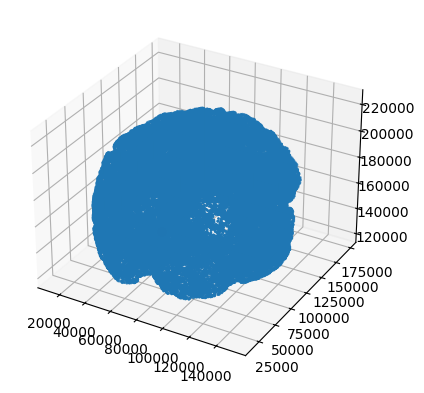

In [ ]:
#%matplotlib qt
# from scipy.interpolate import griddata

#visualization
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# x_neuron, y_neuron, z_neuron = [],[],[]
# for sec in h.allsec():
#     for seg in sec:
#         if 'Scale' in str(seg):
#             continue
#         if 'soma' in str(seg):
#             print(seg.x_xtra,seg.y_xtra,seg.z_xtra)
#         x_neuron.append(seg.x_xtra)
#         y_neuron.append(seg.y_xtra)
#         z_neuron.append(seg.z_xtra)
#         ax.scatter((seg.x_xtra+location[0]*dx)*1e-3,(seg.y_xtra+location[1]*dx)*1e-3,(seg.z_xtra+location[2]*dx)*1e-3,color='k') #um
#         for child in sec.children():
#             ax.plot([(sec.x_xtra+location[0]*dx)*1e-3,(child.x_xtra+location[0]*dx)*1e-3], [(sec.y_xtra+location[1]*dx)*1e-3,(child.y_xtra+location[1]*dx)*1e-3],[(sec.z_xtra+location[2]*dx)*1e-3,(child.z_xtra+location[2]*dx)*1e-3],color='k') #um

# print(np.min(x_neuron),np.max(x_neuron), np.min(y_neuron),np.max(y_neuron), np.min(z_neuron),np.max(z_neuron))
# print(np.min(points[:, 0]),np.max(points[:, 0]), np.min(points[:, 1]),np.max(points[:, 1]), np.min(points[:, 2]),np.max(points[:, 2]))

for i_p,polygon in enumerate(polygons[:1]):
    location, normal = polygon['centroid'], polygon['normal']
    print(f'location_{i_p}: {location}, {normal} ({subject},{direction})')
    _,x_values,y_values,z_values = es_matrix_matf(E_x300,E_y300,E_z300,dx,(0,0,0)) #E_x, E_y and E_z are only used for the shape in this case so doesn't matter which freq: 300 or 100k
    thresh_freqs = np.zeros(numb_freq)
    titr_freqs = np.zeros(numb_freq)
    freq_array = np.logspace(logstart,logstop,numb_freq)  

    for i_f,freq in enumerate(freq_array[:1]):
        print(f'frequency_{i_f}: {freq}')

        if TMS or Bunif:
            h.getcoords() #gets the coordinates and also calculates D_x, D_y and D_z at every segment
            calcESext3(*location*dx,normal,np.array([0,0,1]),interpol,E_x300,E_y300,E_z300,x_values,y_values,z_values) if freq < 1e4 else calcESext3(*location*dx,normal,np.array([0,0,1]),interpol,E_x300,E_y300,E_z300,x_values,y_values,z_values) #calculation of E_x, E_y and E_z at every segment


ax.scatter(points[:, 0]*dx, points[:, 1]*dx, points[:, 2]*dx, s=1) 
plt.show()